In [1]:
from google.colab import files
uploaded = files.upload()

Saving kg_train.csv to kg_train.csv


In [2]:
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing

### SMS: SPAM or HAM

### Let's prepare the environment

In [3]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split


- Read Data for the Fraudulent Email Kaggle Challenge

- Reduce the training set to speead up development.

In [4]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("kg_train.csv", encoding='latin-1')

# Reduce the training set to speed up development.
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("", inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [5]:
# Your code

data.columns

Index(['text', 'label'], dtype='object')

In [6]:
data['label'].value_counts()

,count
label,
0,558
1,442


In [7]:


data_train, data_val = train_test_split(data, test_size= 0.2, random_state= 42 , stratify= data['label'])

In [8]:
print(data_train.shape, data_val.shape)

print(data_train['label'].value_counts(normalize=True))

print(data_val['label'].value_counts(normalize=True))

(800, 2) (200, 2)
label
0    0.5575
1    0.4425
Name: proportion, dtype: float64
label
0    0.56
1    0.44
Name: proportion, dtype: float64


## Data Preprocessing

In [9]:
!pip install nltk


In [10]:
import nltk

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('stopwords')

nltk.download('wordnet')

nltk.download('averaged_perceptron_tagger_eng')

import string

from nltk.corpus import stopwords

print(string.punctuation)

print(stopwords.words("english")[100:110])

from nltk.stem.snowball import SnowballStemmer

snowball = SnowballStemmer('english')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


## Now, we have to clean the html code removing words



- First we remove inline JavaScript/CSS

- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters

- Next we can remove the remaining tags

In [11]:
import re

def strip_html(text):
    text = str(text)
    # 1. Remove inline JavaScript/CSS
    text = re.sub(r'(?is)<(script|style).*?>.*?(</\1>)', '', text)
    # 2. Remove HTML comments (must be done before removing regular tags,
    #    since comments can themselves contain '>' characters)
    text = re.sub(r'(?s)<!--(.*?)-->[\n]?', '', text)
    # 3. Remove the remaining HTML tags
    text = re.sub(r'(?s)<.*?>', ' ', text)
    return text

data_train = data_train.copy()
data_val = data_val.copy()

data_train['text_no_html'] = data_train['text'].apply(strip_html)
data_val['text_no_html'] = data_val['text'].apply(strip_html)

data_train[['text', 'text_no_html']].head(3)

,text,text_no_html
442,Dear=2C Good day hope fine=2Cdear am writting ...,Dear=2C Good day hope fine=2Cdear am writting ...
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...
971,Will do.,Will do.


- Remove all the special characters

    

- Remove numbers

    

- Remove all single characters



- Remove single characters from the start



- Substitute multiple spaces with single space



- Remove prefixed 'b'



- Convert to Lowercase

In [12]:
def clean_text(text):
    text = str(text)

    # Remove prefixed 'b' (byte-string artifact, e.g. from b'...' repr)
    text = re.sub(r"^b'|^b\"", '', text)

    # Remove all special characters (keep only letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove all single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

    # Remove single characters from the start
    text = re.sub(r'^[a-zA-Z]\s+', ' ', text)

    # Substitute multiple spaces with single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()

    return text

data_train['preprocessed_text'] = data_train['text_no_html'].apply(clean_text)
data_val['preprocessed_text'] = data_val['text_no_html'].apply(clean_text)

data_train[['text_no_html', 'preprocessed_text']].head(3)

,text_no_html,preprocessed_text
442,Dear=2C Good day hope fine=2Cdear am writting ...,dear good day hope fine cdear am writting this...
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,from mr henry kaborethe chief auditor incharge...
971,Will do.,will do


## Now let's work on removing stopwords

Remove the stopwords.

In [13]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    filtered = [w for w in tokens if w not in stop_words]
    return ' '.join(filtered)

data_train['preprocessed_text'] = data_train['preprocessed_text'].apply(remove_stopwords)
data_val['preprocessed_text'] = data_val['preprocessed_text'].apply(remove_stopwords)

data_train['preprocessed_text'].head(3)

,preprocessed_text
442,dear good day hope fine cdear writting mail du...
962,mr henry kaborethe chief auditor inchargeforei...
971,


## Tame Your Text with Lemmatization

Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [14]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized)

data_train['preprocessed_text'] = data_train['preprocessed_text'].apply(lemmatize_text)
data_val['preprocessed_text'] = data_val['preprocessed_text'].apply(lemmatize_text)

data_train['preprocessed_text'].head(3)

,preprocessed_text
442,dear good day hope fine cdear writting mail du...
962,mr henry kaborethe chief auditor inchargeforei...
971,


## Bag Of Words

Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

Top 10 words in HAM messages:
  state: 97
  president: 95
  would: 92
  mr: 90
  obama: 80
  percent: 80
  call: 77
  work: 72
  time: 70
  one: 69

Top 10 words in SPAM messages:
  money: 761
  account: 674
  u: 631
  bank: 615
  fund: 600
  e: 529
  transaction: 435
  business: 412
  country: 401
  nbsp: 387


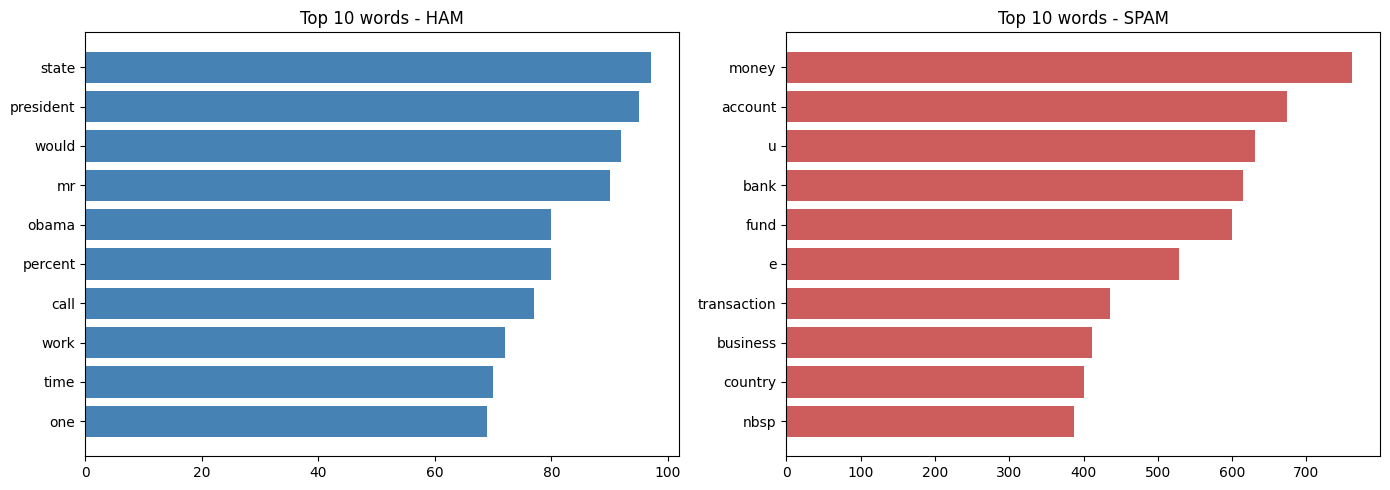

In [15]:
from collections import Counter

def top_words(series, n=10):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

ham_top = top_words(data_train[data_train['label'] == 0]['preprocessed_text'])
spam_top = top_words(data_train[data_train['label'] == 1]['preprocessed_text'])

print("Top 10 words in HAM messages:")
for word, count in ham_top:
    print(f"  {word}: {count}")

print("\nTop 10 words in SPAM messages:")
for word, count in spam_top:
    print(f"  {word}: {count}")

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([w for w, c in ham_top][::-1], [c for w, c in ham_top][::-1], color='steelblue')
axes[0].set_title('Top 10 words - HAM')

axes[1].barh([w for w, c in spam_top][::-1], [c for w, c in spam_top][::-1], color='indianred')
axes[1].set_title('Top 10 words - SPAM')

plt.tight_layout()
plt.show()

## Extra features

In [16]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).

money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])

suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])



data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1

data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1

data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x))



data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1

data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1

data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x))



data_train.head()

,text,label,text_no_html,preprocessed_text,money_mark,suspicious_words,text_len
442,Dear=2C Good day hope fine=2Cdear am writting ...,1,Dear=2C Good day hope fine=2Cdear am writting ...,dear good day hope fine cdear writting mail du...,1,1,1002
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,1,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,mr henry kaborethe chief auditor inchargeforei...,0,1,1946
971,Will do.,0,Will do.,,0,0,0
190,FROM THE DESK OF DR.ADAMU ISMALERAUDITING AND...,1,FROM THE DESK OF DR.ADAMU ISMALERAUDITING AND...,desk dr adamu ismalerauditing accounting manag...,1,1,383
551,"Dear Friend, My name is LOI C.ESTRADA,The wife...",1,"Dear Friend, My name is LOI C.ESTRADA,The wife...",dear friend name loi estrada wife mr josephest...,1,1,1475


## How would work the Bag of Words with Count Vectorizer concept?

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(data_train['preprocessed_text'])

print(f"Shape of the Bag-of-Words matrix: {X_train_counts.shape}")
print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")

# Peek at a few feature names
print(f"Sample features: {count_vectorizer.get_feature_names_out()[:10]}")

Shape of the Bag-of-Words matrix: (800, 28200)
Vocabulary size: 28200
Sample features: ['aa' 'aaa' 'aabeiawaeaambiqaceqedeqh' 'aac' 'aaccount' 'aacute' 'aacw'
 'aae' 'aaecaxeebsexbhjbuqdhcrmimoeifekrobhbcsmzuvavynlrchyknoel'
 'aaegmdbsch']


## TF-IDF



- Load the vectorizer



- Vectorize all dataset



- print the shape of the vetorized dataset

In [18]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf = tfidf_vectorizer.transform(data_val['preprocessed_text'])

print(f"Shape of the TF-IDF training matrix: {X_train_tfidf.shape}")
print(f"Shape of the TF-IDF validation matrix: {X_val_tfidf.shape}")

Shape of the TF-IDF training matrix: (800, 28200)
Shape of the TF-IDF validation matrix: (200, 28200)


## And the Train a Classifier?

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, data_train['label'])

y_pred = nb_model.predict(X_val_tfidf)

print(f"Accuracy: {accuracy_score(data_val['label'], y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(data_val['label'], y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(data_val['label'], y_pred))

Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       112
           1       0.90      1.00      0.95        88

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200


Confusion Matrix:
[[102  10]
 [  0  88]]


### Extra Task - Implement a SPAM/HAM classifier



https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce



The classifier can not be changed!!! It must be the MultinimialNB with default parameters!



Your task is to **find the most relevant features**.



For example, you can test the following options and check which of them performs better:

- Using "Bag of Words" only

- Using "TF-IDF" only

- Bag of Words + extra flags (money_mark, suspicious_words, text_len)

- TF-IDF + extra flags





You can work with teams of two persons (recommended).

In [20]:
import numpy as np
from scipy.sparse import hstack, csr_matrix

# --- Config A: Bag of Words only ---
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bow = bow_vectorizer.transform(data_val['preprocessed_text'])

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, data_train['label'])
acc_bow = accuracy_score(data_val['label'], model_bow.predict(X_val_bow))

# --- Config B: TF-IDF only (reuse X_train_tfidf / X_val_tfidf from above) ---
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, data_train['label'])
acc_tfidf = accuracy_score(data_val['label'], model_tfidf.predict(X_val_tfidf))

# --- Config C: Bag of Words + extra flags ---
extra_train = csr_matrix(data_train[['money_mark', 'suspicious_words', 'text_len']].values)
extra_val = csr_matrix(data_val[['money_mark', 'suspicious_words', 'text_len']].values)

X_train_bow_extra = hstack([X_train_bow, extra_train])
X_val_bow_extra = hstack([X_val_bow, extra_val])

model_bow_extra = MultinomialNB()
model_bow_extra.fit(X_train_bow_extra, data_train['label'])
acc_bow_extra = accuracy_score(data_val['label'], model_bow_extra.predict(X_val_bow_extra))

# --- Config D: TF-IDF + extra flags ---
X_train_tfidf_extra = hstack([X_train_tfidf, extra_train])
X_val_tfidf_extra = hstack([X_val_tfidf, extra_val])

model_tfidf_extra = MultinomialNB()
model_tfidf_extra.fit(X_train_tfidf_extra, data_train['label'])
acc_tfidf_extra = accuracy_score(data_val['label'], model_tfidf_extra.predict(X_val_tfidf_extra))

# --- Compare all 4 configurations ---
results = {
    "Bag of Words only": acc_bow,
    "TF-IDF only": acc_tfidf,
    "Bag of Words + extra flags": acc_bow_extra,
    "TF-IDF + extra flags": acc_tfidf_extra,
}

print("=== MultinomialNB accuracy by feature configuration ===\n")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

best_config = max(results, key=results.get)
print(f"\nBest performing configuration: {best_config} (accuracy: {results[best_config]:.4f})")

=== MultinomialNB accuracy by feature configuration ===

Bag of Words only: 0.9700
TF-IDF only: 0.9500
Bag of Words + extra flags: 0.8500
TF-IDF + extra flags: 0.6150

Best performing configuration: Bag of Words only (accuracy: 0.9700)


### Conclusion

**Bag of Words only achieved the best performance (accuracy 0.9700)**, slightly outperforming
TF-IDF only (0.9500). Both text-only vectorizations performed substantially better than the
configurations that included the extra flags (money_mark, suspicious_words, text_len).

Surprisingly, adding the extra flags **hurt** performance rather than helping — Bag of Words +
extra flags dropped to 0.8500, and TF-IDF + extra flags collapsed to 0.6150. The most likely
explanation is a **scale mismatch**: `text_len` is a raw integer (potentially in the hundreds),
while both Bag-of-Words counts and TF-IDF weights operate on a much smaller, more uniform scale.
MultinomialNB treats its inputs as if they were comparable "counts," so a single feature with
a much larger numeric range can dominate the model's learned weights and distort its decisions —
especially with TF-IDF, whose values are already normalized to a 0-1 range and are therefore
even more sensitive to being overwhelmed by an unscaled feature.

**Takeaway**: this dataset's spam/ham signal is already well captured by the vectorized text
alone — simple word frequency patterns (Bag of Words) are enough to separate the classes
effectively. The engineered flags could still be useful in principle, but would need to be
scaled (e.g. normalized or binned) before being combined with sparse text features, rather
than concatenated raw.